In [56]:
# CELL 1

from pathlib import Path
import json

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from api.process_ai.process.pipeline.process_configs import get_process_config
from api.process_ai.process.pipeline.orchestrator import (
    TrainParams,
    train_process_from_key,
)

In [57]:
# CELL 2

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "api").exists() and (p / "model").exists():
            return p
    raise FileNotFoundError("Could not find project root")

def to_abs_path(path_like: str | Path, project_root: Path) -> Path:
    p = Path(path_like)
    return p if p.is_absolute() else (project_root / p).resolve()

PROJECT_ROOT = find_project_root()

PROCESS_KEYS = ["trucking", "warehouse", "customs"]

process_cfgs = {k: get_process_config(k) for k in PROCESS_KEYS}
process_report_dirs = {
    k: to_abs_path(process_cfgs[k].report_dir, PROJECT_ROOT)
    for k in PROCESS_KEYS
}
process_monitor_dirs = {
    k: process_report_dirs[k] / "monitoring"
    for k in PROCESS_KEYS
}

SHARED_REPORT_DIR = PROJECT_ROOT / "reports" / "cross_process"
SHARED_REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SHARED_REPORT_DIR:", SHARED_REPORT_DIR)

for k in PROCESS_KEYS:
    print(k, "->", process_monitor_dirs[k])

PROJECT_ROOT: D:\logistics_AI
SHARED_REPORT_DIR: D:\logistics_AI\reports\cross_process
trucking -> D:\logistics_AI\reports\trucking\monitoring
warehouse -> D:\logistics_AI\reports\warehouse\monitoring
customs -> D:\logistics_AI\reports\customs\monitoring


In [58]:
# CELL 3

mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use("default")

PRIMARY = "#1f4e79"
SECONDARY = "#5b9bd5"
ACCENT = "#9dc3e6"
GRID = "#d9d9d9"
TEXT = "#222222"

PROCESS_COLOR_MAP = {
    "trucking": "#1f4e79",
    "warehouse": "#ed7d31",
    "customs": "#70ad47",
}

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["axes.edgecolor"] = "#cccccc"
plt.rcParams["axes.labelcolor"] = TEXT
plt.rcParams["xtick.color"] = TEXT
plt.rcParams["ytick.color"] = TEXT
plt.rcParams["text.color"] = TEXT
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11

def style_axes(ax, grid_axis="x"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.grid(axis=grid_axis, color=GRID, linestyle="-", linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)

def save_and_show(fig, path: Path):
    fig.tight_layout()
    fig.savefig(path, dpi=240, bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved:", path)

In [59]:
# CELL 4

def safe_read_csv(path: Path) -> pd.DataFrame | None:
    if not path.exists():
        return None
    try:
        return pd.read_csv(path)
    except Exception as e:
        print(f"Could not read CSV: {path} -> {e}")
        return None

def safe_read_json(path: Path) -> dict | None:
    if not path.exists():
        return None
    try:
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print(f"Could not read JSON: {path} -> {e}")
        return None

In [60]:
# CELL 5

monthly_monitoring_frames = []
drift_summary_frames = []
trigger_rule_frames = []
monitoring_summary_frames = []
train_summary_rows = []

for process_key in PROCESS_KEYS:
    monitor_dir = process_monitor_dirs[process_key]
    report_dir = process_report_dirs[process_key]

    monthly_df = safe_read_csv(monitor_dir / f"{process_key}_monthly_monitoring.csv")
    if monthly_df is not None:
        monthly_df["process_key"] = process_key
        monthly_monitoring_frames.append(monthly_df)

    drift_df = safe_read_csv(monitor_dir / f"{process_key}_drift_summary.csv")
    if drift_df is not None:
        drift_df["process_key"] = process_key
        drift_summary_frames.append(drift_df)

    trigger_df = safe_read_csv(monitor_dir / f"{process_key}_retrain_trigger_rules.csv")
    if trigger_df is not None:
        trigger_df["process_key"] = process_key
        trigger_rule_frames.append(trigger_df)

    monitoring_df = safe_read_csv(monitor_dir / f"{process_key}_monitoring_summary.csv")
    if monitoring_df is not None:
        monitoring_df["process_key"] = process_key
        monitoring_summary_frames.append(monitoring_df)

    train_json = safe_read_json(report_dir / f"{process_key}_train_summary_snapshot.json")
    if train_json is not None:
        train_json["process_key"] = process_key
        train_summary_rows.append(train_json)

monthly_monitoring_all_df = pd.concat(monthly_monitoring_frames, ignore_index=True) if monthly_monitoring_frames else pd.DataFrame()
drift_summary_all_df = pd.concat(drift_summary_frames, ignore_index=True) if drift_summary_frames else pd.DataFrame()
trigger_rules_all_df = pd.concat(trigger_rule_frames, ignore_index=True) if trigger_rule_frames else pd.DataFrame()
monitoring_summary_all_df = pd.concat(monitoring_summary_frames, ignore_index=True) if monitoring_summary_frames else pd.DataFrame()
train_summary_all_df = pd.DataFrame(train_summary_rows)

print("monthly_monitoring_all_df:", monthly_monitoring_all_df.shape)
print("drift_summary_all_df:", drift_summary_all_df.shape)
print("trigger_rules_all_df:", trigger_rules_all_df.shape)
print("monitoring_summary_all_df:", monitoring_summary_all_df.shape)
print("train_summary_all_df:", train_summary_all_df.shape)

monthly_monitoring_all_df: (11, 8)
drift_summary_all_df: (3, 15)
trigger_rules_all_df: (12, 5)
monitoring_summary_all_df: (3, 10)
train_summary_all_df: (3, 11)


In [61]:
# CELL 6

display(monthly_monitoring_all_df.head())
display(drift_summary_all_df)
display(trigger_rules_all_df.head())
display(monitoring_summary_all_df)

,month,case_count,avg_risk,p95_risk,avg_anomaly,high_risk_rate,critical_rate,process_key
0,2025-04,3782,48.982813,94.0,0.409806,19.116869,23.796933,trucking
1,2025-05,4147,49.850735,95.0,0.410833,20.786110,24.017362,trucking
2,2025-06,3955,49.591909,94.0,0.410292,20.101138,22.932996,trucking
3,2025-07,116,50.698276,96.0,0.413358,17.241379,25.862069,trucking
4,2025-04,3915,49.808174,94.0,0.413649,20.842912,19.412516,warehouse


,reference_months,recent_months,avg_risk_ref,avg_risk_recent,avg_risk_delta,p95_risk_ref,p95_risk_recent,p95_risk_delta,high_risk_rate_ref,high_risk_rate_recent,high_risk_rate_delta,critical_rate_ref,critical_rate_recent,critical_rate_delta,process_key
0,"2025-04, 2025-05, 2025-06","2025-05, 2025-06, 2025-07",49.475153,50.046973,0.571821,94.333333,95.000000,0.666667,20.001373,19.376209,-0.625163,23.582430,24.270809,0.688379,trucking
1,"2025-04, 2025-05, 2025-06","2025-04, 2025-05, 2025-06",49.506892,49.506892,0.000000,94.333333,94.333333,0.000000,20.007350,20.007350,0.000000,18.997562,18.997562,0.000000,warehouse
2,"2025-04, 2025-05, 2025-06","2025-05, 2025-06, 2025-07",49.522568,48.208255,-1.314314,94.233333,93.683333,-0.550000,19.989432,22.953866,2.964434,11.009458,9.635229,-1.374229,customs


,rule,value,threshold,triggered,process_key
0,Average risk delta,0.571821,5.0,False,trucking
1,P95 risk delta,0.666667,5.0,False,trucking
2,High-risk rate delta,-0.625163,5.0,False,trucking
3,Critical rate delta,0.688379,3.0,False,trucking
4,Average risk delta,0.000000,5.0,False,warehouse


,process_code,cases_analyzed,cases_ok,avg_risk,p95_risk,high_risk_cases_80plus,high_risk_rate_80plus,critical_cases,critical_rate,process_key
0,TRUCKING_DELIVERY_FLOW,12000,12000,49.500083,94.05,2400,20.000000,2833,23.608333,trucking
1,WAREHOUSE_FULFILLMENT,12000,12000,49.500083,94.05,2400,20.000000,2279,18.991667,warehouse
2,IMPORT_CUSTOMS_CLEARANCE,4286,4286,49.500700,94.75,858,20.018665,471,10.989267,customs


In [62]:
# CELL 7

for col in ["avg_risk", "p95_risk", "high_risk_rate", "critical_rate"]:
    if col in monthly_monitoring_all_df.columns:
        monthly_monitoring_all_df[col] = pd.to_numeric(monthly_monitoring_all_df[col], errors="coerce")

for col in ["avg_risk_delta", "p95_risk_delta", "high_risk_rate_delta", "critical_rate_delta"]:
    if col in drift_summary_all_df.columns:
        drift_summary_all_df[col] = pd.to_numeric(drift_summary_all_df[col], errors="coerce")

if "triggered" in trigger_rules_all_df.columns:
    trigger_rules_all_df["triggered"] = trigger_rules_all_df["triggered"].astype(str).str.lower().map(
        {"true": True, "false": False}
    ).fillna(trigger_rules_all_df["triggered"])

display(monthly_monitoring_all_df.head())

,month,case_count,avg_risk,p95_risk,avg_anomaly,high_risk_rate,critical_rate,process_key
0,2025-04,3782,48.982813,94.0,0.409806,19.116869,23.796933,trucking
1,2025-05,4147,49.850735,95.0,0.410833,20.786110,24.017362,trucking
2,2025-06,3955,49.591909,94.0,0.410292,20.101138,22.932996,trucking
3,2025-07,116,50.698276,96.0,0.413358,17.241379,25.862069,trucking
4,2025-04,3915,49.808174,94.0,0.413649,20.842912,19.412516,warehouse


In [63]:
# CELL 8

retrain_status_rows = []

for process_key in PROCESS_KEYS:
    part = trigger_rules_all_df[trigger_rules_all_df["process_key"] == process_key].copy()

    triggered_rules = part[part["triggered"] == True]["rule"].tolist()
    retrain_status_rows.append({
        "process_key": process_key,
        "triggered_rule_count": len(triggered_rules),
        "triggered_rules": "; ".join(triggered_rules) if triggered_rules else "",
        "retrain_recommended": len(triggered_rules) > 0,
    })

retrain_status_df = pd.DataFrame(retrain_status_rows)

display(retrain_status_df)

,process_key,triggered_rule_count,triggered_rules,retrain_recommended
0,trucking,0,,False
1,warehouse,0,,False
2,customs,0,,False


In [64]:
# CELL 9

active_count = int(retrain_status_df["retrain_recommended"].fillna(False).sum())

if active_count == 0:
    print("Executive summary:")
    print("- No retrain trigger is active across all processes.")
    print("- Current system status is stable.")
    print("- No immediate retraining action is recommended.")
else:
    active_processes = retrain_status_df.loc[
        retrain_status_df["retrain_recommended"] == True,
        "process_key"
    ].astype(str).str.upper().tolist()

    print("Executive summary:")
    print(f"- {active_count} process(es) currently require retraining review.")
    print(f"- Triggered processes: {', '.join(active_processes)}")

Executive summary:
- No retrain trigger is active across all processes.
- Current system status is stable.
- No immediate retraining action is recommended.


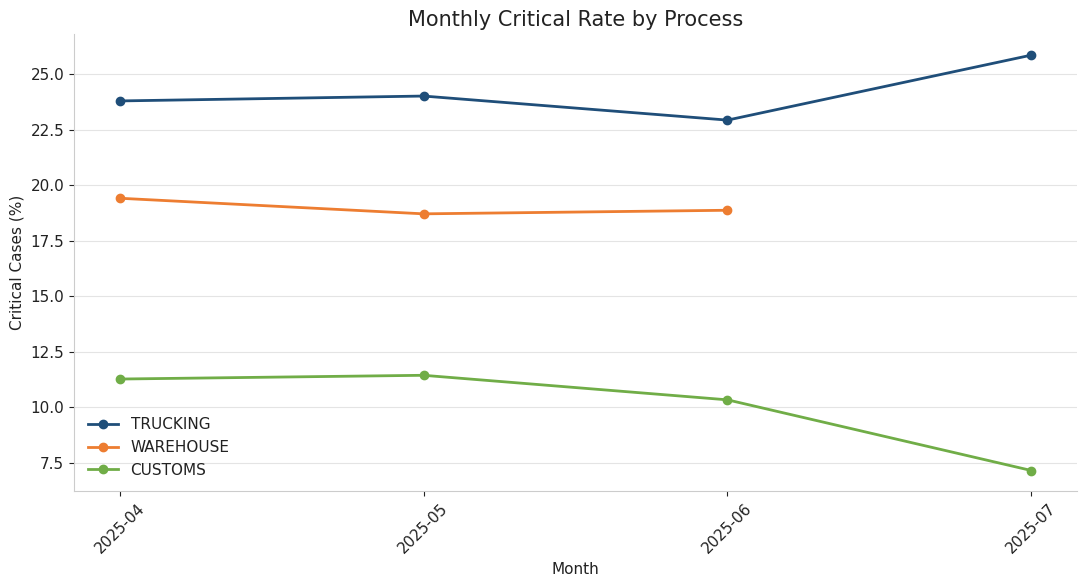

Saved: D:\logistics_AI\reports\cross_process\cross_process_monthly_critical_rate.png


In [65]:
# CELL 10

fig, ax = plt.subplots(figsize=(11, 6))

for process_key in PROCESS_KEYS:
    part = monthly_monitoring_all_df[monthly_monitoring_all_df["process_key"] == process_key].copy()
    if part.empty:
        continue

    part = part.sort_values("month")

    ax.plot(
        part["month"],
        part["critical_rate"],
        marker="o",
        linewidth=2,
        label=process_key.upper(),
        color=PROCESS_COLOR_MAP.get(process_key, SECONDARY),
    )

ax.set_title("Monthly Critical Rate by Process")
ax.set_xlabel("Month")
ax.set_ylabel("Critical Cases (%)")
style_axes(ax, grid_axis="y")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)

critical_trend_path = SHARED_REPORT_DIR / "cross_process_monthly_critical_rate.png"
save_and_show(fig, critical_trend_path)

In [66]:
# CELL 11

priority_df = monitoring_summary_all_df.merge(
    drift_summary_all_df[
        ["process_key", "avg_risk_delta", "p95_risk_delta", "high_risk_rate_delta", "critical_rate_delta"]
    ],
    on="process_key",
    how="left",
).merge(
    retrain_status_df[
        ["process_key", "triggered_rule_count", "retrain_recommended"]
    ],
    on="process_key",
    how="left",
)

for col in [
    "avg_risk", "p95_risk", "high_risk_rate_80plus", "critical_rate",
    "avg_risk_delta", "p95_risk_delta", "high_risk_rate_delta", "critical_rate_delta",
    "triggered_rule_count"
]:
    if col in priority_df.columns:
        priority_df[col] = pd.to_numeric(priority_df[col], errors="coerce")

priority_df["priority_score"] = (
    priority_df["triggered_rule_count"].fillna(0) * 5
    + priority_df["p95_risk_delta"].fillna(0) * 0.8
    + priority_df["critical_rate_delta"].fillna(0) * 1.2
    + priority_df["high_risk_rate_delta"].fillna(0) * 0.8
    + priority_df["critical_rate"].fillna(0) * 0.2
)

priority_df = priority_df.sort_values("priority_score", ascending=False)

display(priority_df)

,process_code,cases_analyzed,cases_ok,avg_risk,p95_risk,high_risk_cases_80plus,high_risk_rate_80plus,critical_cases,critical_rate,process_key,avg_risk_delta,p95_risk_delta,high_risk_rate_delta,critical_rate_delta,triggered_rule_count,retrain_recommended,priority_score
0,TRUCKING_DELIVERY_FLOW,12000,12000,49.500083,94.05,2400,20.000000,2833,23.608333,trucking,0.571821,0.666667,-0.625163,0.688379,0,False,5.580924
1,WAREHOUSE_FULFILLMENT,12000,12000,49.500083,94.05,2400,20.000000,2279,18.991667,warehouse,0.000000,0.000000,0.000000,0.000000,0,False,3.798333
2,IMPORT_CUSTOMS_CLEARANCE,4286,4286,49.500700,94.75,858,20.018665,471,10.989267,customs,-1.314314,-0.550000,2.964434,-1.374229,0,False,2.480325


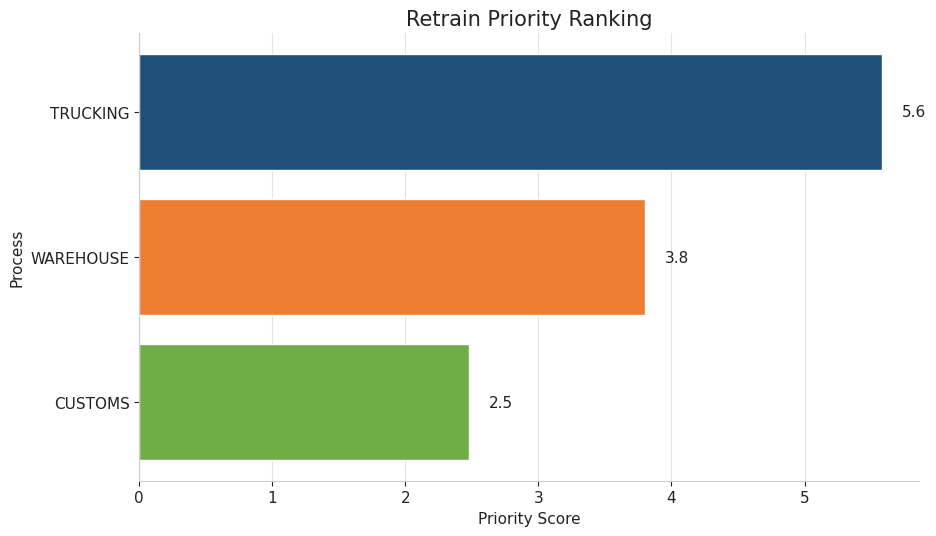

Saved: D:\logistics_AI\reports\cross_process\cross_process_retrain_priority.png


In [67]:
# CELL 12

plot_df = priority_df.sort_values("priority_score", ascending=True).copy()

if plot_df["priority_score"].fillna(0).sum() == 0:
    print("No meaningful retrain priority signal detected. Skipping chart.")
    display(plot_df[["process_key", "priority_score", "retrain_recommended", "triggered_rule_count"]])
else:
    fig, ax = plt.subplots(figsize=(9.5, 5.5))

    bars = ax.barh(
        plot_df["process_key"].str.upper(),
        plot_df["priority_score"],
        color=[PROCESS_COLOR_MAP.get(x, SECONDARY) for x in plot_df["process_key"]],
        edgecolor="white",
    )

    ax.set_title("Retrain Priority Ranking")
    ax.set_xlabel("Priority Score")
    ax.set_ylabel("Process")
    style_axes(ax, grid_axis="x")

    for bar in bars:
        w = bar.get_width()
        ax.text(w + 0.15, bar.get_y() + bar.get_height()/2, f"{w:.1f}", va="center", ha="left")

    priority_rank_path = SHARED_REPORT_DIR / "cross_process_retrain_priority.png"
    save_and_show(fig, priority_rank_path)

In [68]:
# CELL 13

retrain_action_df = priority_df[
    [
        "process_key",
        "priority_score",
        "triggered_rule_count",
        "retrain_recommended",
        "p95_risk_delta",
        "critical_rate_delta",
        "high_risk_rate_delta",
    ]
].copy()

display(retrain_action_df)

,process_key,priority_score,triggered_rule_count,retrain_recommended,p95_risk_delta,critical_rate_delta,high_risk_rate_delta
0,trucking,5.580924,0,False,0.666667,0.688379,-0.625163
1,warehouse,3.798333,0,False,0.000000,0.000000,0.000000
2,customs,2.480325,0,False,-0.550000,-1.374229,2.964434


In [69]:
# CELL 14

RUN_RETRAIN = False

RETRAIN_PARAM_MAP = {
    "trucking": TrainParams(n_estimators=300, contamination=0.06, random_state=42),
    "warehouse": TrainParams(n_estimators=300, contamination=0.06, random_state=42),
    "customs": TrainParams(n_estimators=300, contamination=0.06, random_state=42),
}

top_process_to_retrain = priority_df.iloc[0]["process_key"] if not priority_df.empty else None
print("Top process to retrain:", top_process_to_retrain)
print("RUN_RETRAIN:", RUN_RETRAIN)

Top process to retrain: trucking
RUN_RETRAIN: False


In [70]:
# CELL 15

retrain_result_payload = None

if RUN_RETRAIN and top_process_to_retrain is not None:
    cfg = process_cfgs[top_process_to_retrain]
    data_dir = to_abs_path(cfg.data_dir, PROJECT_ROOT)
    registry_dir = to_abs_path(cfg.registry_dir, PROJECT_ROOT)
    model_dir = to_abs_path(cfg.model_dir, PROJECT_ROOT)

    retrain_result_payload = train_process_from_key(
        top_process_to_retrain,
        params=RETRAIN_PARAM_MAP[top_process_to_retrain],
        data_dir=str(data_dir),
        registry_dir=str(registry_dir),
        model_root_dir=str(model_dir),
    )

    display(pd.DataFrame([retrain_result_payload["train_summary"]]))
else:
    print("Retrain not executed.")

Retrain not executed.


In [71]:
# CELL 16

headline_monitor_df = priority_df[
    [
        "process_key",
        "priority_score",
        "retrain_recommended",
        "triggered_rule_count",
        "avg_risk",
        "p95_risk",
        "critical_rate",
        "avg_risk_delta",
        "p95_risk_delta",
        "high_risk_rate_delta",
        "critical_rate_delta",
    ]
].copy()

display(headline_monitor_df)

,process_key,priority_score,retrain_recommended,triggered_rule_count,avg_risk,p95_risk,critical_rate,avg_risk_delta,p95_risk_delta,high_risk_rate_delta,critical_rate_delta
0,trucking,5.580924,False,0,49.500083,94.05,23.608333,0.571821,0.666667,-0.625163,0.688379
1,warehouse,3.798333,False,0,49.500083,94.05,18.991667,0.000000,0.000000,0.000000,0.000000
2,customs,2.480325,False,0,49.500700,94.75,10.989267,-1.314314,-0.550000,2.964434,-1.374229


In [72]:
# CELL 17

retrain_status_df.to_csv(SHARED_REPORT_DIR / "cross_process_retrain_status.csv", index=False)
priority_df.to_csv(SHARED_REPORT_DIR / "cross_process_retrain_priority.csv", index=False)
headline_monitor_df.to_csv(SHARED_REPORT_DIR / "cross_process_monitoring_headline.csv", index=False)

generated_files = [
    SHARED_REPORT_DIR / "cross_process_retrain_trigger_count.png",
    SHARED_REPORT_DIR / "cross_process_monthly_critical_rate.png",
    SHARED_REPORT_DIR / "cross_process_retrain_priority.png",
    SHARED_REPORT_DIR / "cross_process_retrain_status.csv",
    SHARED_REPORT_DIR / "cross_process_retrain_priority.csv",
    SHARED_REPORT_DIR / "cross_process_monitoring_headline.csv",
]

if retrain_result_payload is not None:
    retrain_json_path = SHARED_REPORT_DIR / "cross_process_last_retrain_result.json"
    with open(retrain_json_path, "w", encoding="utf-8") as f:
        json.dump(retrain_result_payload, f, ensure_ascii=False, indent=2)
    generated_files.append(retrain_json_path)

for f in generated_files:
    print(f.exists(), "-", f)

True - D:\logistics_AI\reports\cross_process\cross_process_retrain_trigger_count.png
True - D:\logistics_AI\reports\cross_process\cross_process_monthly_critical_rate.png
True - D:\logistics_AI\reports\cross_process\cross_process_retrain_priority.png
True - D:\logistics_AI\reports\cross_process\cross_process_retrain_status.csv
True - D:\logistics_AI\reports\cross_process\cross_process_retrain_priority.csv
True - D:\logistics_AI\reports\cross_process\cross_process_monitoring_headline.csv
